<a href="https://colab.research.google.com/github/saitejakchintaginjal/AIML-Projects/blob/main/Personal_Loan_Campaign_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
PL_campaign_data = pd.read_csv('/content/drive/MyDrive/Loan_Modelling.csv')

In [ ]:
df = PL_campaign_data.copy()

# Understand the Data

In [ ]:
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
df.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


In [ ]:
df.shape

(5000, 14)

Observation :
* There are 5000 rows and 14 columns, which means 5000 customers and 14 features

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


Observations:
* Every column has a 5000 non-null values. This indicates there are no missing/null values in the dataset.
* 13 columns are of type int64 and only one column is of type float64.
* All features are numerical.


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


Observations:
1. Age
* Mean age is approximately 45 years.
* Customer range from 23 to 67.
* Majority customers fall between 35 to 55 years.
2. Experience
* Average experience is around 20 years.
* Minimum value is -3, which is unrealistic.
* Negative experience indicates data inconsistency/outliers that need treatment.
* Most customers have 10 to 30 years of experience.
3. Income
* Average income is about 73.77.
* Income ranges from 8 to 224.
* Large difference between mean and max suggests the presence of high-income outliers.
4. ZIPCode
* ZIPCode represents location, it should be treated as a categorical/geographical variable, not continuous numerical data.
5. Family
* Family size ranges from 1 to 4.
* Median family size is 2.
6. CCAvg
* Average monthly credit card spending is approximately 1.94.
* Maximum value is 10, much higher than the median (1.5).
7. Education
* This is an categorical variable representing education levels.
8. Mortgage
* Median mortgage value is 0.
* 75% value is 101, while maximum is 635.
* Distribution is highly skewed with significant outliers.
9. Personal_Loan
* Mean is 0.096.
* Indicates only about 9.6% customers accepted/took personal loans.
* Dataset is imbalanced because:
   * Majority class = 0 (No Loan)
   * Minority class = 1 (Loan)
10. Securities_Account
* Mean = 0.104
* About 10.4% customers have a securities account.
11. CD_Account
* Mean = 0.0604
* Only 6% customers have a CD account.
12. Online
* Mean = 0.5968
* Around 60% customers use online banking.
13. CreditCard
* Mean = 0.294
* Approximately 29.4% customers use credit cards issued by the bank.

In [ ]:
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


Observation :
* No missing values.

In [ ]:
df.duplicated().sum()

np.int64(0)

Observation :
* No duplicated values.

In [ ]:
df.drop(['ID','ZIPCode'], axis=1, inplace=True)

ID and ZIPCode usually do not help in prediction, so let's drop these two columns

# Univariate Analysis

Numerical Features Distribution

In [ ]:

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )

    # Boxplot
    sns.boxplot(
        data=data,
        x=feature,
        ax=ax_box,
        showmeans=True,
        color="violet"
    )

    # Histogram
    if bins:
      sns.histplot(
        data=data,
        x=feature,
        kde=kde,
        ax=ax_hist,
        bins=bins,
        color="skyblue"
    )
    else:
      sns.histplot(
        data=data,
        x=feature,
        kde=kde,
        ax=ax_hist,
        color="skyblue"
    )

    # Mean line
    ax_hist.axvline(
        data[feature].mean(),
        color="green",
        linestyle="--",
        linewidth=2,
        label="Mean"
    )

    # Median line
    ax_hist.axvline(
        data[feature].median(),
        color="black",
        linestyle="-.",
        linewidth=2,
        label="Median"
    )

    ax_hist.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def countplot_with_labels(data, feature, figsize=(8, 5), perc=False, top_n=None):

    plt.figure(figsize=figsize)

    # Get category order
    order = data[feature].value_counts().index
    if top_n:
        order = order[:top_n]

    ax = sns.countplot(
        data=data,
        x=feature,
        order=order,
        hue=feature,
        palette="Paired",
        legend=False
    )

    total = len(data)

    # Add labels on bars
    for p in ax.patches:
        height = p.get_height()

        if perc:
            label = f"{100 * height / total:.1f}%"
        else:
            label = f"{int(height)}"

        ax.annotate(
            label,
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.xticks(rotation=45)
    plt.title(f"Countplot of {feature}")
    plt.tight_layout()
    plt.show()

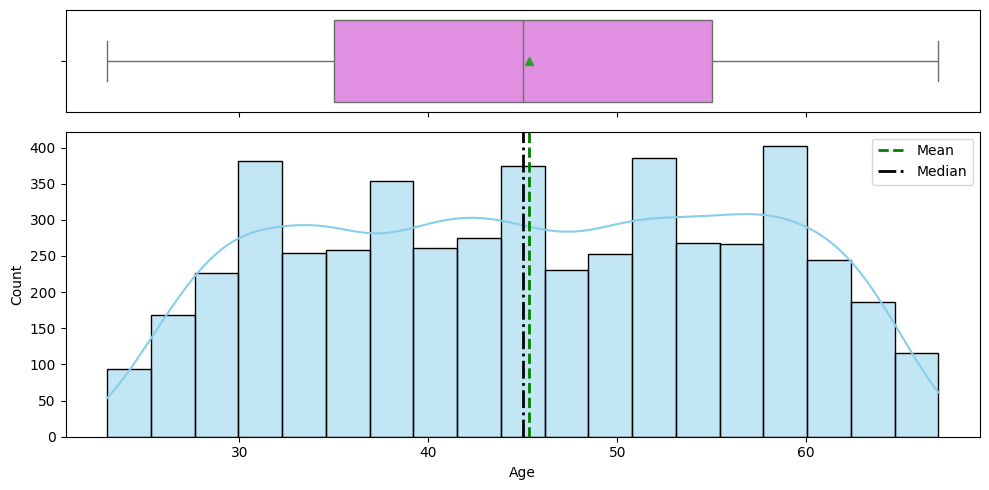

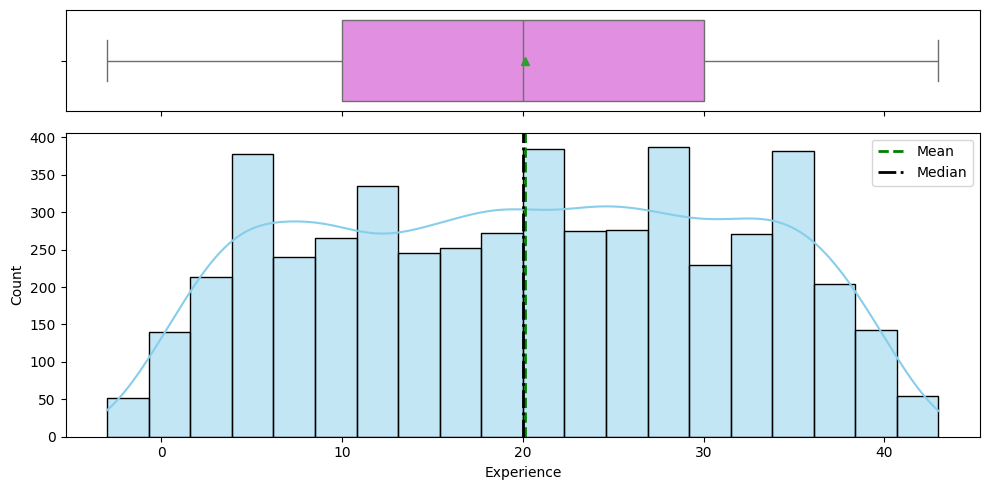

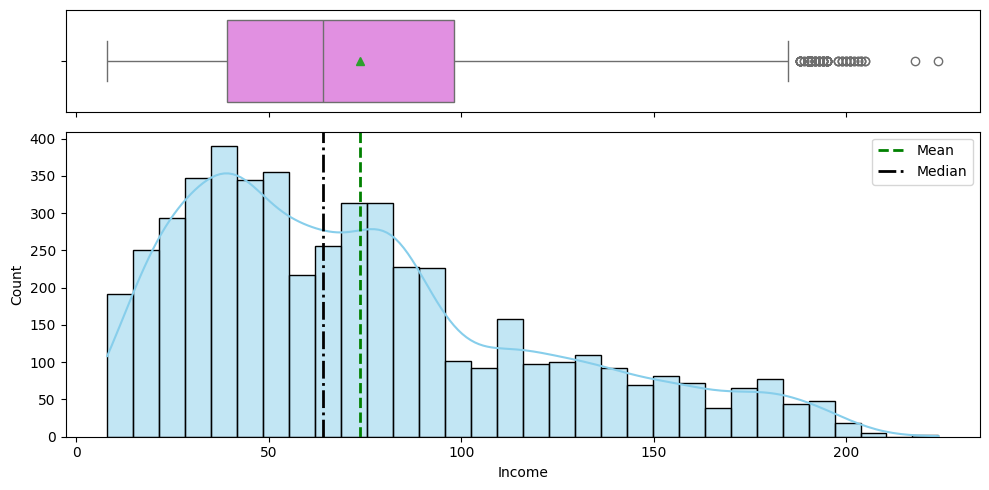

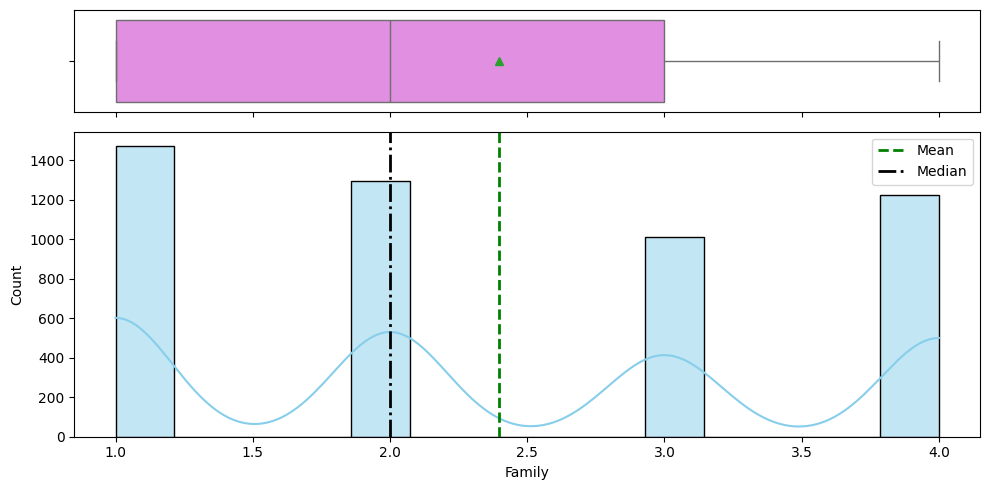

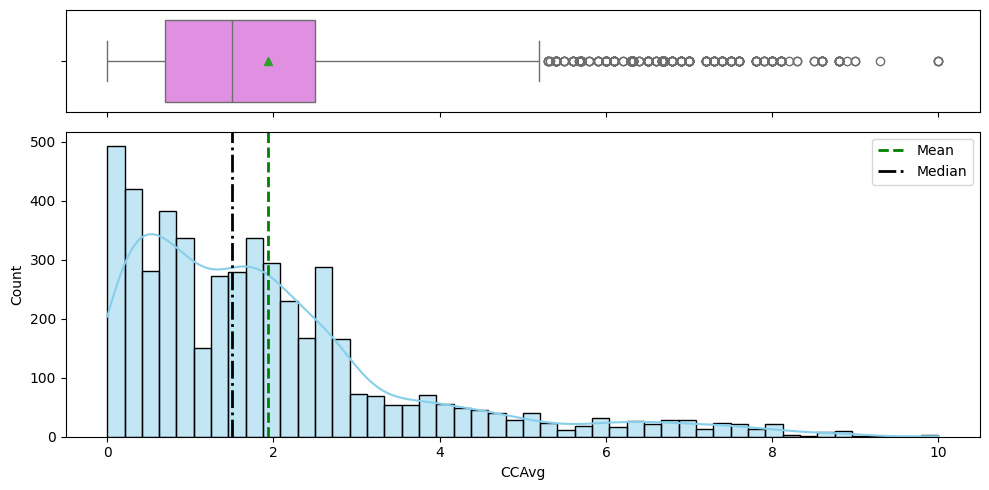

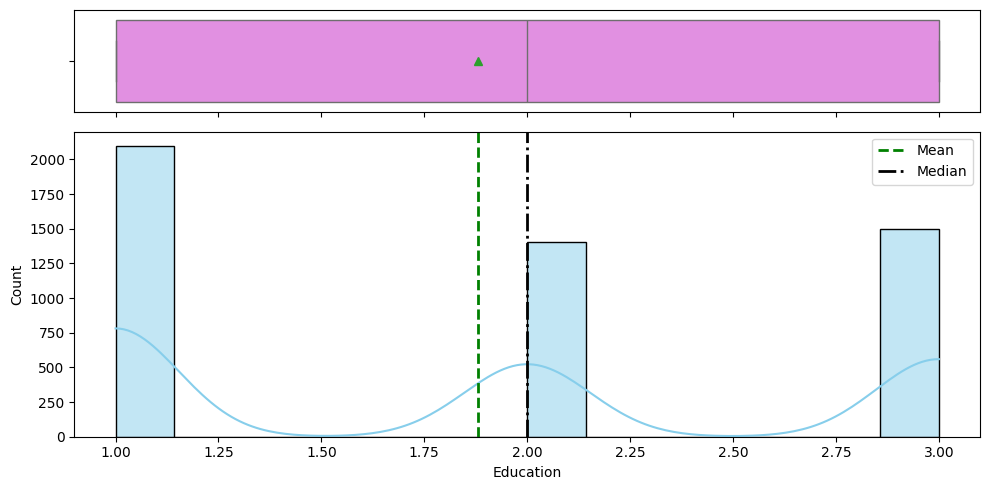

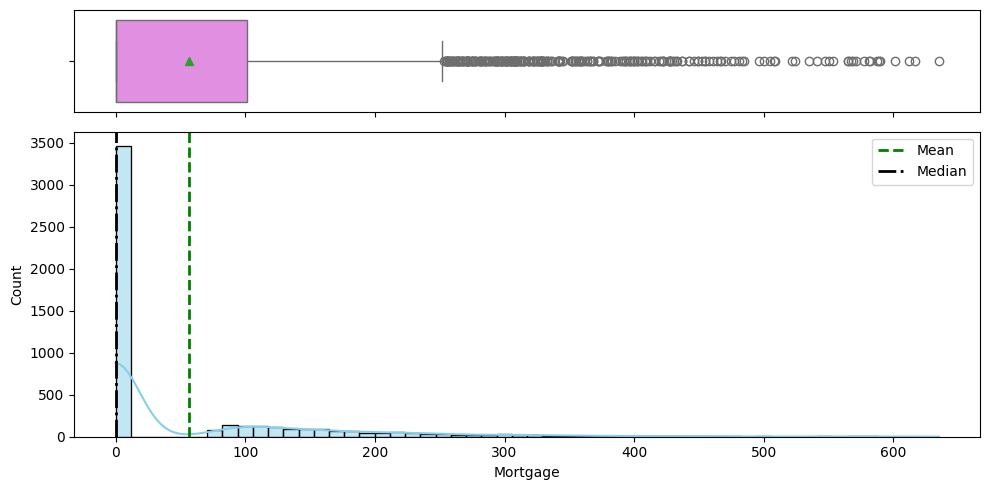

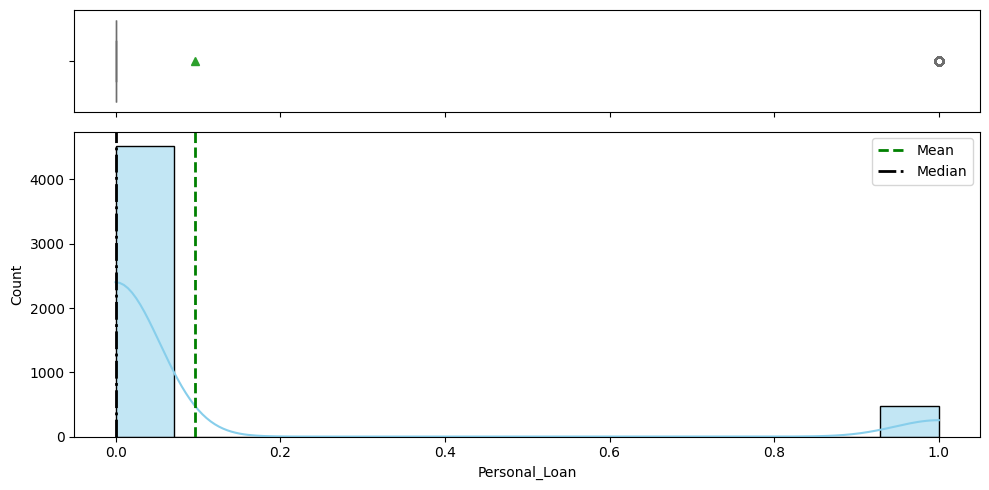

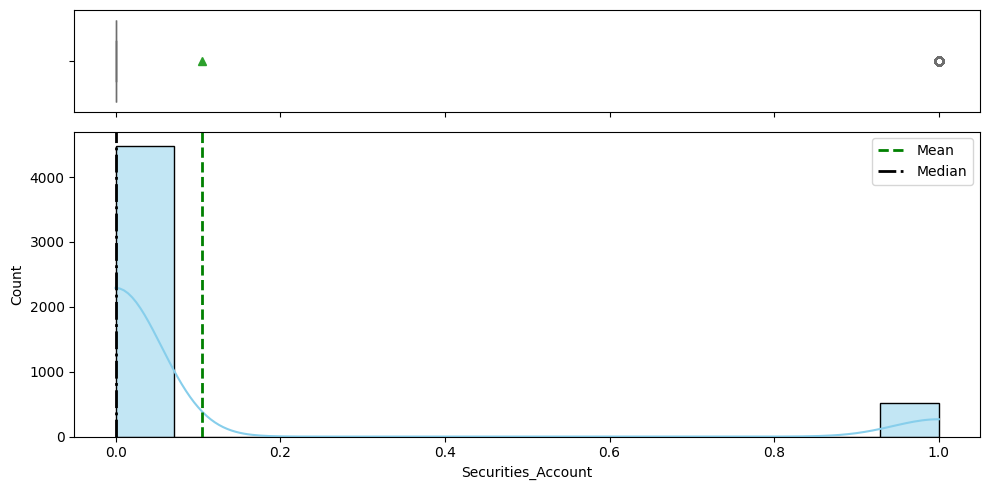

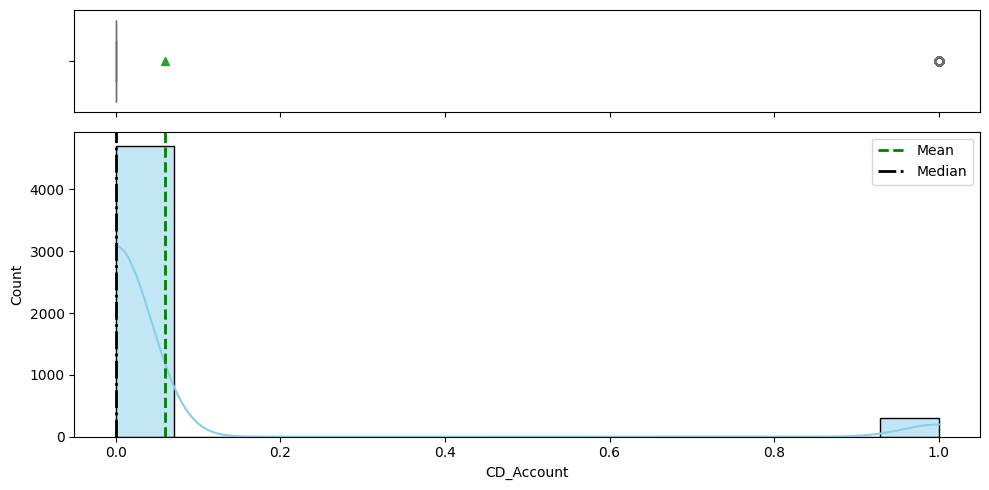

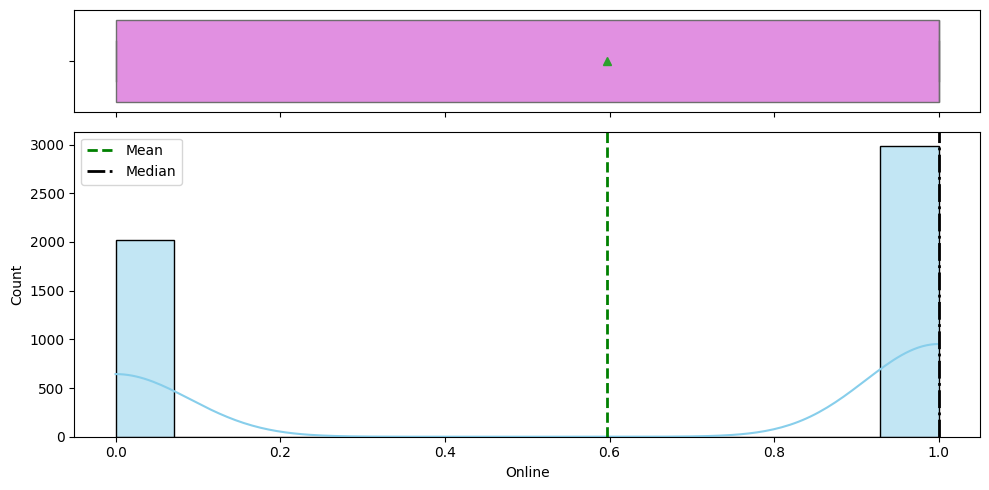

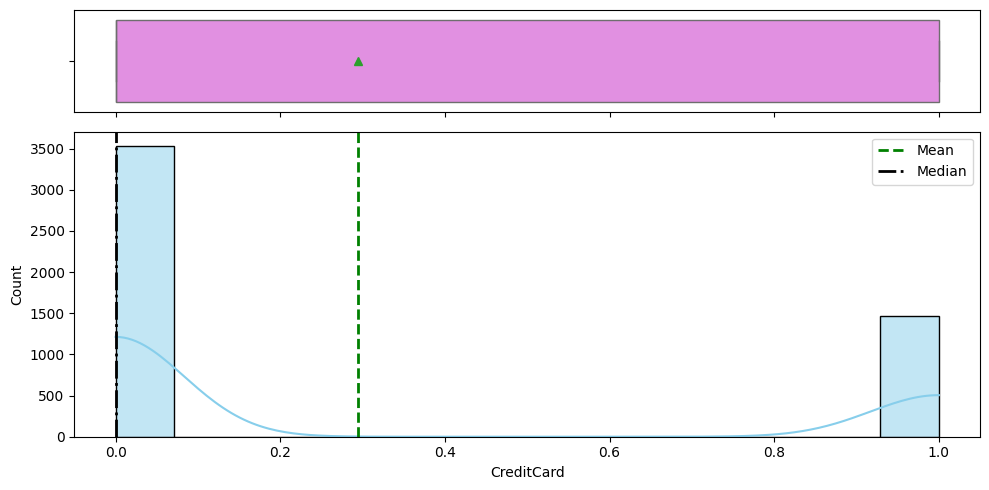

In [ ]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    histogram_boxplot(
        data=df,
        feature=col,
        figsize=(10, 5),
        kde=True,
    )

Observations:
1. Age
* Age is approximately uniformly distributed between 25 and 67 years.
* Mean and median are almost identical, indicating a symmetric distribution.
* No major outliers observed.
2. Experience
* Experience ranges from about 0 to 43 years.
* Mean and median overlap closely, suggesting a balanced distribution.
* No notable outliers.
3. Income
* Distribution is right-skewed.
* Mean is greater than median due to high-income customers.
* Majority of customers have income below 100.
* Few customers have very high income, indicating outliers.
4. Family
* Discrete variable with values from 1 to 4.
* Family sizes 1 and 2 are most common.
* Mean is slightly higher than median due to the presence of larger families.
* No meaningful outliers.
5. CCAvg
* Strongly right-skewed.
* Most customers have low credit card spending.
* Few customers spend heavily, creating a long tail.
* Outliers are present.
6. Education
* Discrete/ordinal feature with values 1, 2, 3.
* Category 1 appears most frequent.
* Mean and median are close.
7. Mortgage
* Extremely right-skewed.
* Large number of customers have Zero mortgage.
* Few customers have very high mortgage values.
* Extreme outliers exist.
8. Personal_Loan
* Highly imbalanced dataset.
* Majority of customers did not take a personal loan.
* Very few customers belong to class 1.
9. Securities_Account
* Very few customers have securities accounts.
10. CD_Account
* Very small proportion of customers have CD accounts.
11. Online
* More customers use online banking than not.
12. CreditCard
* Majority of customers do not use the banks credit card.
* Moderate imbalance present.

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    countplot_with_labels(
        data=df,
        feature=col,
        perc=True,
        figsize=(8, 5)
    )

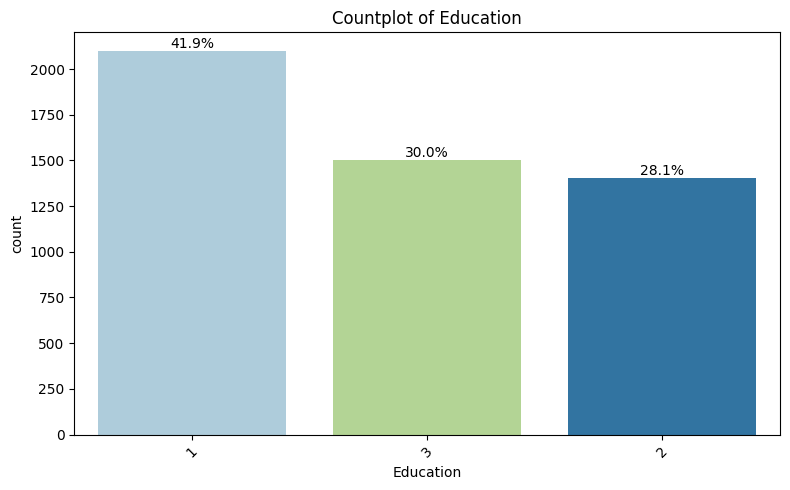

In [ ]:
countplot_with_labels(df, "Education", perc=True)

Observations :
* Education Level 1 has the highest number of customers, accounting for 41.9% of the dataset.
* Education Level 3 represents 30.0% of customers.
* Education Level 2 represents 28.1% of customers and is the least common category.
* The distribution is moderately imbalanced, with Education Level 1 having a noticeably larger share than the other two categories.
* Education Levels 2 and 3 have relatively similar proportions, differing by only about 2 percentage points.
* Since all categories have substantial representation, the Education variable is unlikely to cause issues related to sparse categories during modeling.

Target Variable Distribution

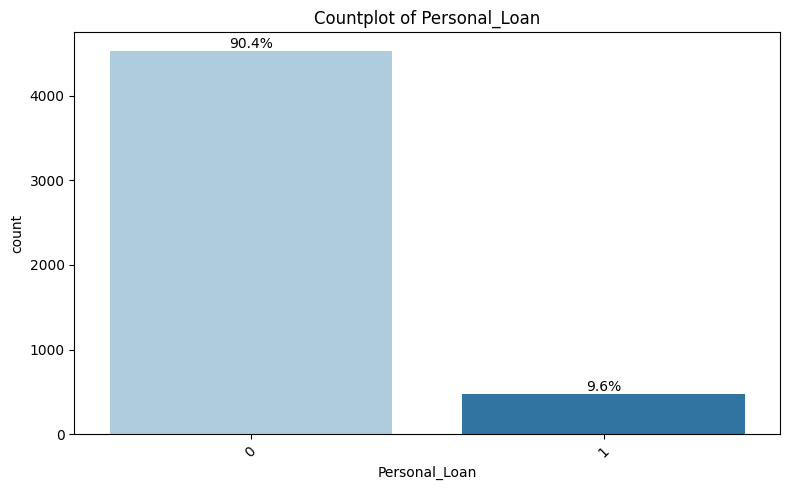

In [ ]:
countplot_with_labels(df, "Personal_Loan", perc=True)

Observations :
* A large majority of customers did not accept the personal loan offer (Personal_Loan = 0).
* Only 9.6% of customers accepted the personal loan offer (Personal_Loan = 1).
* The target variable is highly imbalanced, with the non-loan class significantly outnumbering the loan class.
* This indicates that personal loan acceptance is a relatively rare event among customers.
* For predictive modeling, this class imbalance should be considered, as models may become biased toward predicting the majority class.

# Correlation Analysis

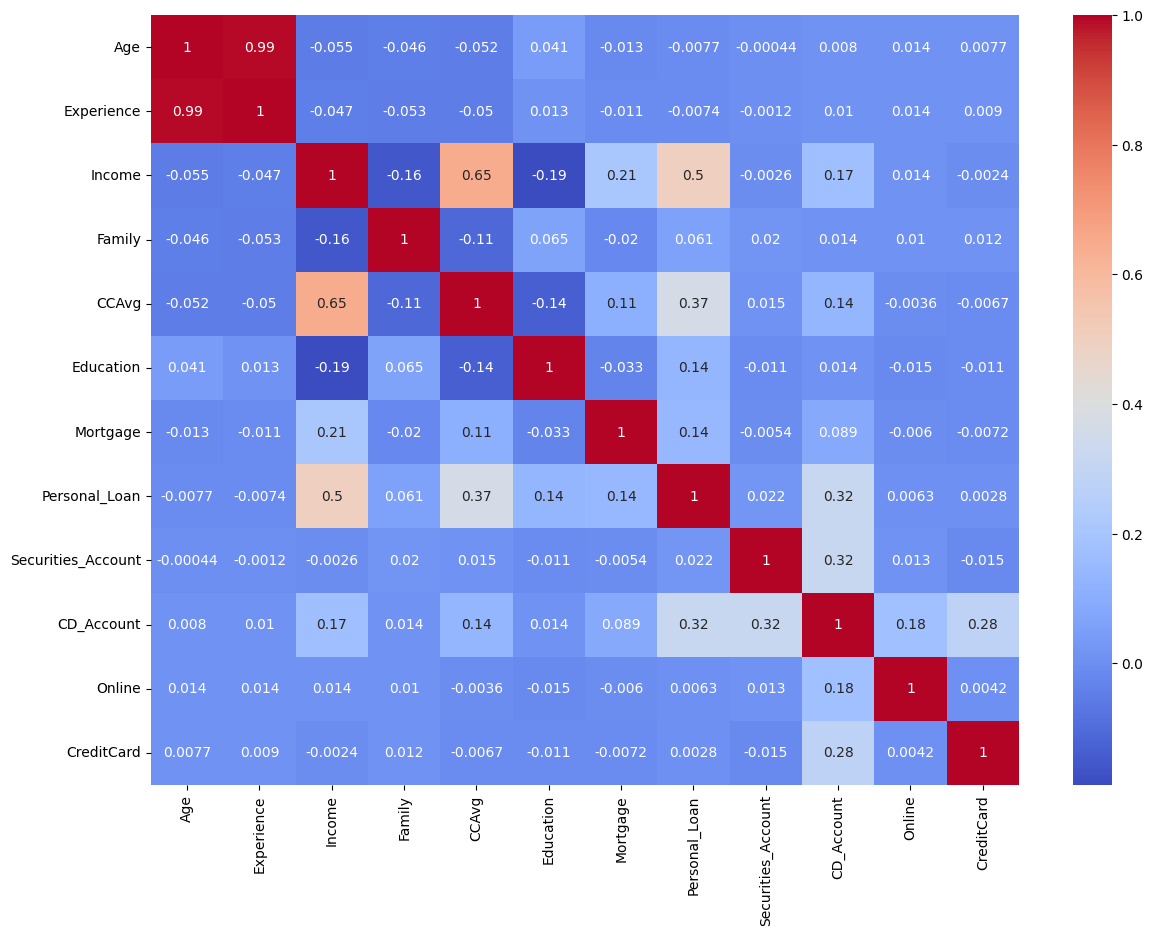

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.show()

Observations :
* Age and Experience have a very strong positive correlation (0.99), indicating multicollinearity.
* Income has the highest correlation with Personal_Loan (0.50), making it an important predictor.
* CCAvg is moderately positively correlated with Personal_Loan (0.37).
* Customers with a CD_Account are more likely to take personal loans (0.32 correlation).
* Income and CCAvg are strongly positively correlated (0.65).
* Most other variables show weak or near-zero correlation with Personal_Loan.
* Online, CreditCard, and Securities_Account have very low correlation with loan acceptance.
* Negative correlations in the dataset are generally weak and not significant.
* No strong negative relationships are observed among variables.
* Income, CCAvg, and CD_Account appear to be the most influential features for predicting personal loan acceptance.

In [ ]:
df.drop('Age', axis=1, inplace=True)

# Loan vs Education

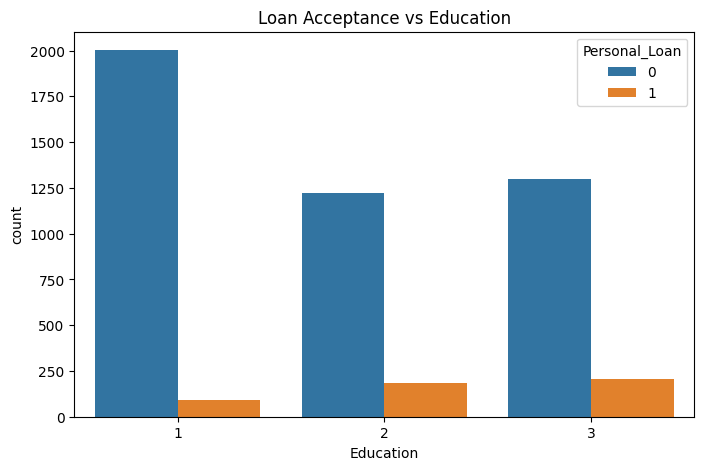

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Education',
              hue='Personal_Loan',
              data=df)

plt.title("Loan Acceptance vs Education")
plt.show()

In [ ]:
pd.crosstab(
    df['Education'],
    df['Personal_Loan'],
    normalize='index'
) * 100

Personal_Loan,0,1
Education,,
1,95.562977,4.437023
2,87.027798,12.972202
3,86.342438,13.657562


Observations :
* Customers with higher education levels are more likely to accept personal loans.
* Education level 1 has the lowest loan acceptance rate.
* Education levels 2 and 3 have significantly higher loan acceptance rates.
* Majority of customers across all education levels did not take personal loans.
* Customers with professional/advanced education appear more interested in personal loan products.
* Education can be considered an important feature for predicting loan acceptance.


# Loan vs Income

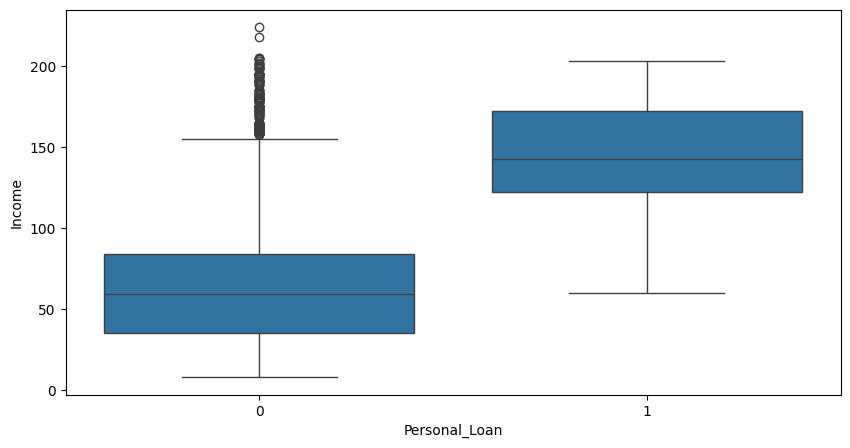

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(x='Personal_Loan',
            y='Income',
            data=df)

plt.show()

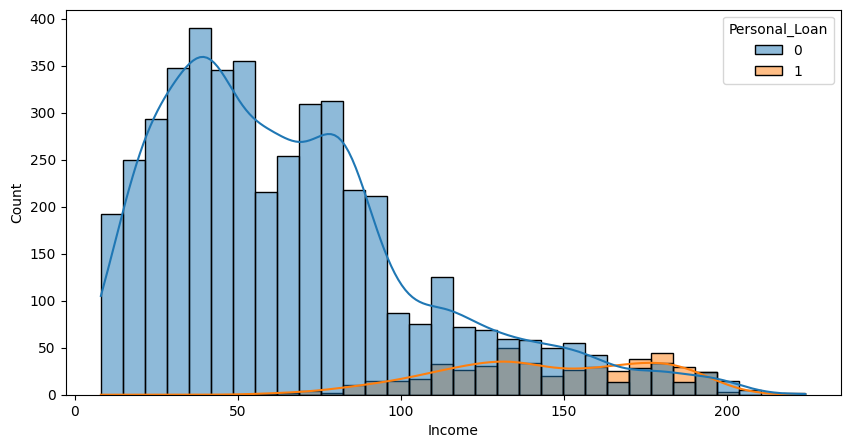

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(data=df,
             x='Income',
             hue='Personal_Loan',
             kde=True)

plt.show()

Observations :
* Customers with higher income are more likely to accept personal loans.
* Loan accepters have a significantly higher median income than non-accepters.
* Income distribution is positively skewed with some high-income outliers.
* Income is a strong predictor of personal loan acceptance.

# Loan vs Credit Card spending

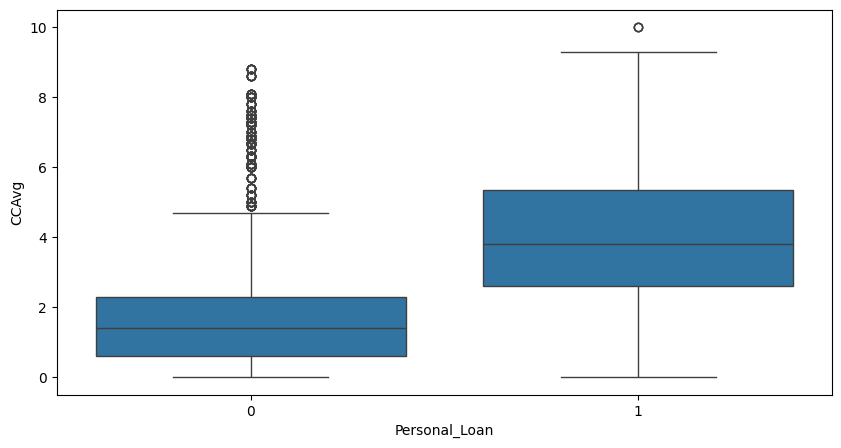

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(x='Personal_Loan',
            y='CCAvg',
            data=df)

plt.show()

Observations :
* Customers with higher CCAvg are more likely to accept personal loans.
* CCAvg shows a positive relationship with personal loan acceptance.
* Some outliers are present in the non-loan group.
* Customers with low credit card spending mostly did not accept loans.

# Loan vs CD Account

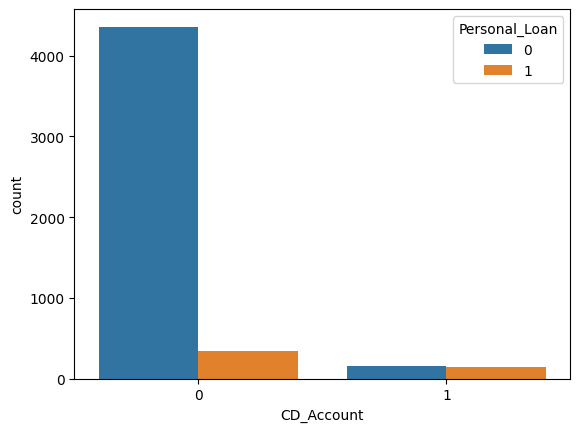

In [ ]:
sns.countplot(x='CD_Account',
              hue='Personal_Loan',
              data=df)

plt.show()

Observations :
* Customers with a CD_Account are much more likely to accept personal loans.
* Loan acceptance is significantly higher among customers who have a CD account.
* Most customers without a CD account did not take personal loans.

Outlier Treatment

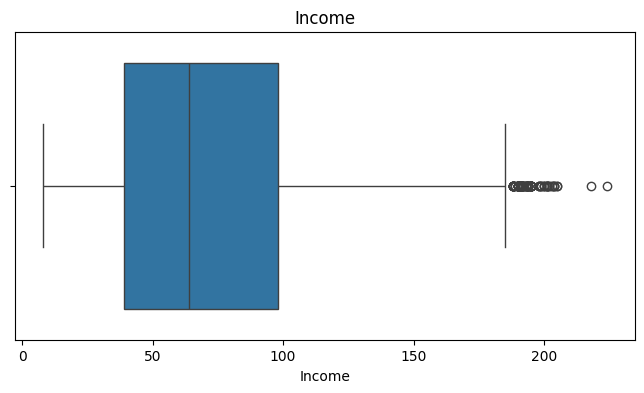

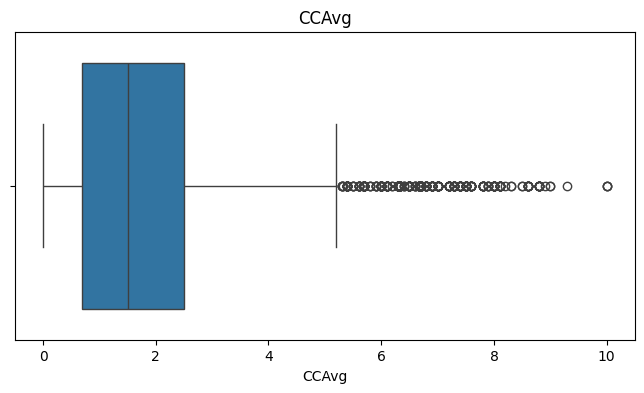

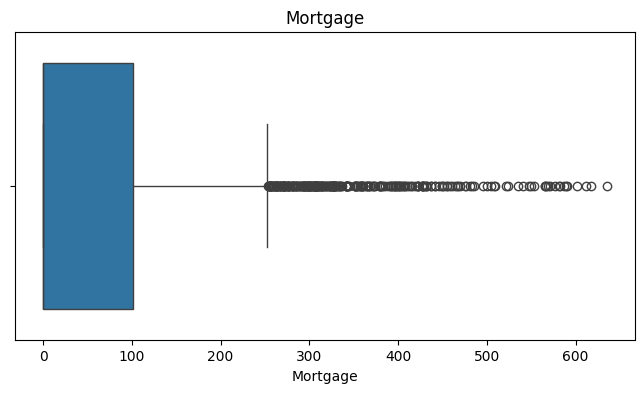

In [ ]:
for col in ['Income', 'CCAvg', 'Mortgage']:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

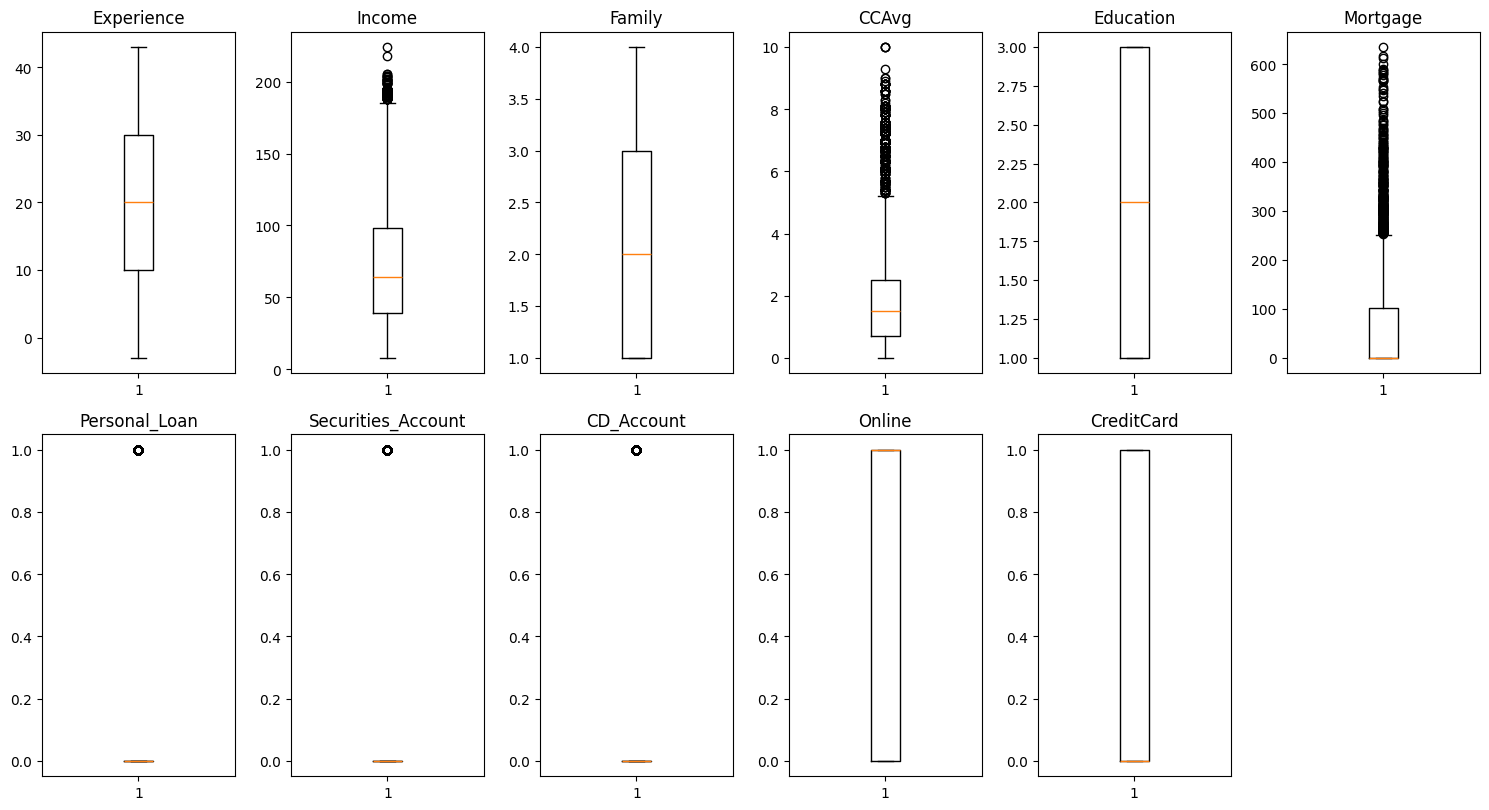

In [ ]:
# outlier detection using boxplot
num_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(num_cols):
    plt.subplot(3, 6, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

Observations :
* Income, CCAvg, and Mortgage contain significant outliers.
* Mortgage has the highest number of extreme outliers and is highly right-skewed.
* Income also shows several high-income outliers.
* CCAvg has many upper-end outliers indicating high credit card spending for some customers.
* Age and Experience do not show major outliers and appear fairly symmetric.
* Family and Education are discrete variables with limited ranges.
* Binary variables (Personal_Loan, Securities_Account, CD_Account, Online, CreditCard) are concentrated around 0 and 1, so boxplots are less informative for them.
* Most customers have low or zero mortgage values.
* Overall, the dataset contains skewed distributions and outliers mainly in financial-related features.

In [ ]:
X = df.drop('Personal_Loan', axis=1)
y = df['Personal_Loan']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Dimensionality Reduction

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(scaled_df)

tsne_2d_data = pd.DataFrame(X_tsne, columns=['Feature 1', 'Feature 2'])

In [ ]:
tsne_2d_data.head()

,Component 1,Component 2
0,31.024654,53.619892
1,28.354034,54.060551
2,37.595734,-28.017750
3,15.335320,-65.709953
4,43.761238,18.590136


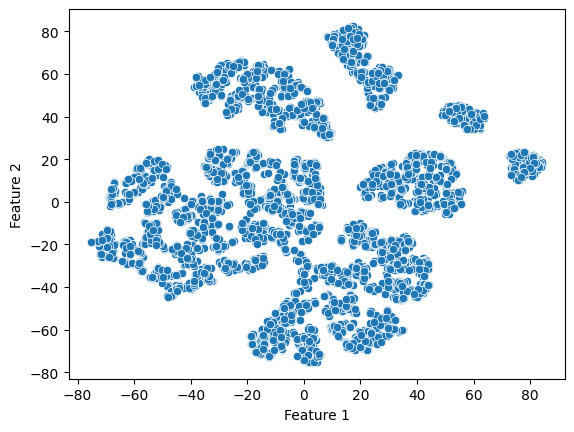

In [ ]:
sns.scatterplot(data=tsne_2d_data, x="Feature 1", y="Feature 2");

Observations :
* There are Multiple Distinct Clusters.
* The dataset contains meaningfull underlying patterns.
* Good separation between groups.
* Many clusters are well-separated with visible gaps between them.
* Some regions contain highly concentrated points.
* A few smaller clusters appear detached from larger groups.
* Relationships between variables are nonlinear

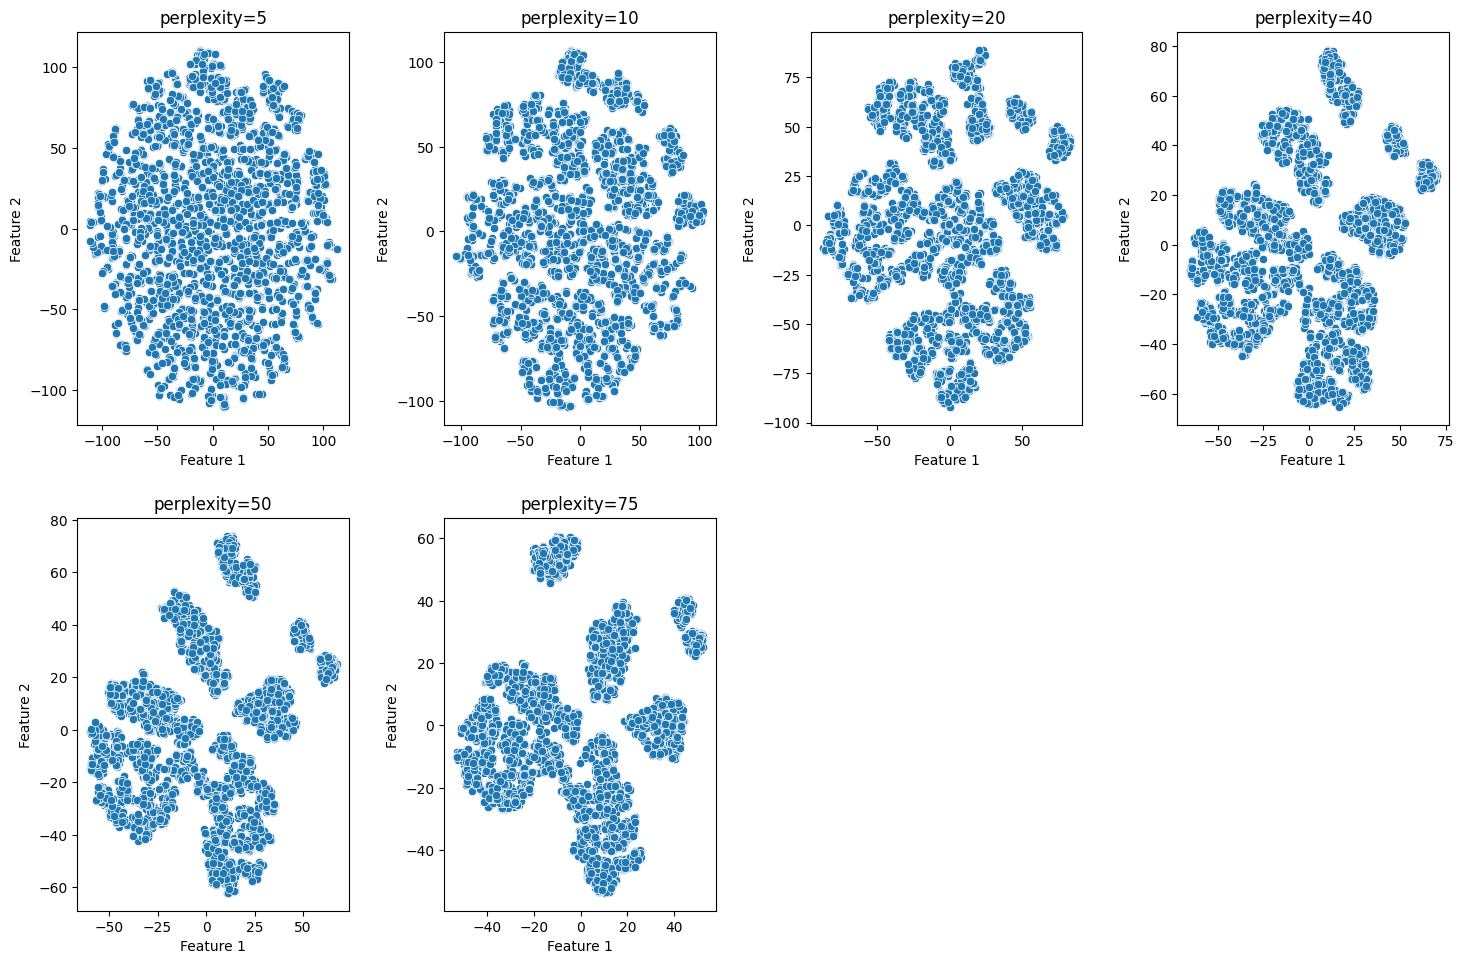

In [ ]:
perplexities = [5, 10, 20, 40, 50, 75]

plt.figure(figsize=(15, 10))

for i in range(len(perplexities)):
    tsne = TSNE(n_components=2, perplexity=perplexities[i], n_jobs=-2, random_state=42)
    X_red = tsne.fit_transform(scaled_df)
    red_data_df = pd.DataFrame(data=X_red, columns=["Feature 1", "Feature 2"])

    plt.subplot(2, 4, i + 1)

    plt.title("perplexity=" + str(perplexities[i]))
    sns.scatterplot(data=red_data_df, x="Feature 1", y="Feature 2")
    plt.tight_layout(pad=2)

plt.show()

Observations :
* At lower perplexity values (5 and 10), the t-SNE visualization appears crowded and less structured, with weak cluster separation.
* As perplexity increases to 20, clearer group formations begin to emerge.
* Perplexity values around 40 and 50 provide the most balanced and well-separated cluster structures.
* At very high perplexity (75), clusters become more compressed and some local structures begin to merge.
* Perplexity values between 40 and 50 produce the clearest visualization of customer groupings for this dataset.

In [ ]:
tsne = TSNE(n_components=2, perplexity=40, n_jobs=-2, random_state=42)

tsne_reduced_data = tsne.fit_transform(scaled_df)

# Creating a DataFrame from the reduced data
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2"]))
tsne_2d_data.head()

,Feature 1,Feature 2
0,26.366440,56.806789
1,23.838295,56.670204
2,28.417427,-19.430700
3,29.448990,-57.893917
4,39.729366,10.993351


Observations :
* t-SNE reduced the high-dimensional customer data into 2 dimensions for visualization.
* Perplexity value of 40 produced clearer and more balanced cluster separation.
* Multiple distinct customer groups can be observed in the visualization.
* The transformed features can help in understanding the underlying structure of the data visually.

In [ ]:
tsne = TSNE(n_components=3, perplexity=40, n_jobs=-2, random_state=42)

tsne_reduced_data = tsne.fit_transform(scaled_df)

tsne_3d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2","Feature 3"]))

In [ ]:
tsne_3d_data.head()

,Feature 1,Feature 2,Feature 3
0,2.975776,5.613464,-20.175615
1,3.905481,5.970624,-18.376966
2,13.240731,-5.511474,-2.762170
3,5.417569,-20.151461,-5.125125
4,17.463034,6.960791,5.258908


In [ ]:
fig = px.scatter_3d(tsne_3d_data, x='Feature 1', y='Feature 2', z='Feature 3')
fig.show()

# Model Building

In [ ]:
k_means_df = scaled_df.copy()

In [ ]:
clusters = range(2, 11)
WCSS = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_df)
    prediction = model.predict(k_means_df)

    wcss = model.inertia_

    WCSS.append(wcss)

    print("Number of Clusters:", k, "\twcss:", wcss)

Number of Clusters: 2 	wcss: 43425.15938721179
Number of Clusters: 3 	wcss: 38063.019712766
Number of Clusters: 4 	wcss: 34689.58779489503
Number of Clusters: 5 	wcss: 31243.874835766816
Number of Clusters: 6 	wcss: 29270.44412321841
Number of Clusters: 7 	wcss: 28379.828853192637
Number of Clusters: 8 	wcss: 25725.074656923032
Number of Clusters: 9 	wcss: 24888.758288053505
Number of Clusters: 10 	wcss: 24055.122552706845


Observations :
* WCSS decreases consistently as the number of clusters increases, which is expected behavior in KMeans clustering.
* A sharp reduction in WCSS is observed from k=2 to k=4, indicating improved cluster compactness.
* After k=4 or k=5, the decrease in WCSS becomes more gradual.
* This suggests that the optimal number of clusters may lie around 4 or 5 based on the Elbow Method.

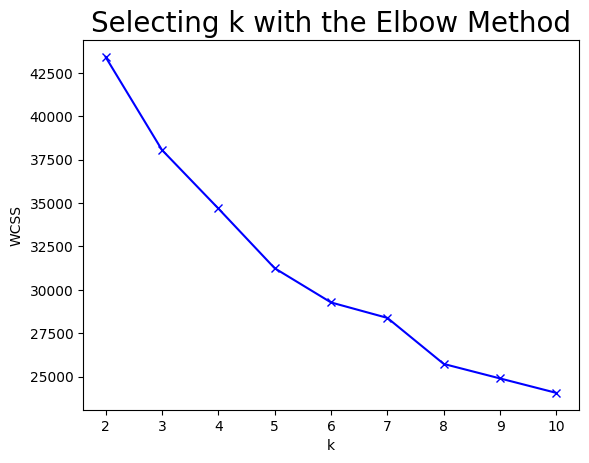

In [ ]:
plt.plot(clusters,WCSS,"bx-")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

Observations :
* The Elbow Method graph shows a sharp decrease in WCSS from k=2 to k=5.
* After k=5, the reduction in WCSS becomes more gradual.
* This indicates that adding more clusters beyond 5 provides smaller improvements in cluster compactness.
* The elbow point appears around k=4 or k=5.

In [ ]:
sil_score = []
cluster_list = range(2, 10)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=42)
    preds = clusterer.fit_predict((scaled_df))
    score = silhouette_score(k_means_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

For n_clusters = 2, the silhouette score is 0.2221322550947073)
For n_clusters = 3, the silhouette score is 0.18824057013570897)
For n_clusters = 4, the silhouette score is 0.20888805623834633)
For n_clusters = 5, the silhouette score is 0.17813860189884853)
For n_clusters = 6, the silhouette score is 0.14653048461023158)
For n_clusters = 7, the silhouette score is 0.14947360807536383)
For n_clusters = 8, the silhouette score is 0.15102485653598705)
For n_clusters = 9, the silhouette score is 0.15866548797275778)


Observations :
* The silhouette score is highest for k=2 with a score of approximately 0.22.
* Scores decrease gradually as the number of clusters increases beyond 2.
* This indicates that cluster separation becomes weaker with higher values of k.
* Although the Elbow Method suggested 4–5 clusters, the Silhouette Method favors fewer clusters.
* The relatively low silhouette scores overall suggest moderate overlap between customer groups, which is common in real-world customer segmentation datasets.

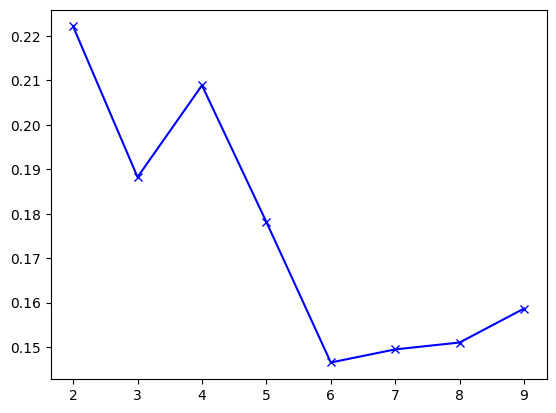

In [ ]:
plt.plot(cluster_list, sil_score, "bx-")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(k_means_df)

KMeans(n_clusters=3, random_state=42)

In [ ]:
df1 = df.copy()

k_means_df["K_means_segments"] = kmeans.labels_    # scaled
df1["K_means_segments"] = kmeans.labels_    # original
tsne_2d_data["K_means_segments"] = kmeans.labels_    # t-SNE 2D
tsne_3d_data["K_means_segments"] = kmeans.labels_

# Cluster Profiling

# Visualizing Final Clusters

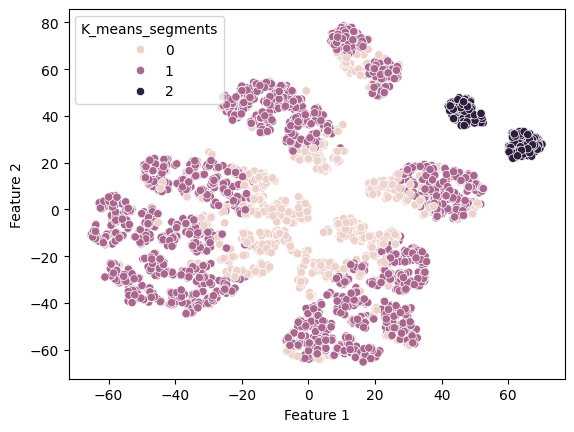

In [ ]:
sns.scatterplot(data=tsne_2d_data, x='Feature 1', y='Feature 2', hue='K_means_segments');

In [ ]:
fig = px.scatter_3d(tsne_3d_data, x='Feature 1', y='Feature 2', z='Feature 3',color='K_means_segments')
fig.show()

In [ ]:
km_cluster_profile = df1.groupby("K_means_segments").mean()

In [ ]:
km_cluster_profile["count_in_each_segment"] = (
    df1.groupby("K_means_segments")["Income"].count().values
)

In [ ]:
km_cluster_profile.style.highlight_max(color="green", axis=0)

,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,count_in_each_segment
K_means_segments,,,,,,,,,,,,
0,19.136095,130.742181,1.797971,3.751090,1.406593,94.075232,0.244294,0.058326,0.000000,0.553677,0.218935,1183
1,20.390327,51.953627,2.592319,1.246856,2.036700,40.774111,0.014509,0.087055,0.000000,0.582077,0.276245,3515
2,20.572848,104.589404,2.460265,2.878974,1.927152,92.324503,0.463576,0.486755,1.000000,0.937086,0.794702,302


In [ ]:
plot_cols = [
    'Income',
    'CCAvg',
    'Mortgage',
    'Experience',
    'Family'
]

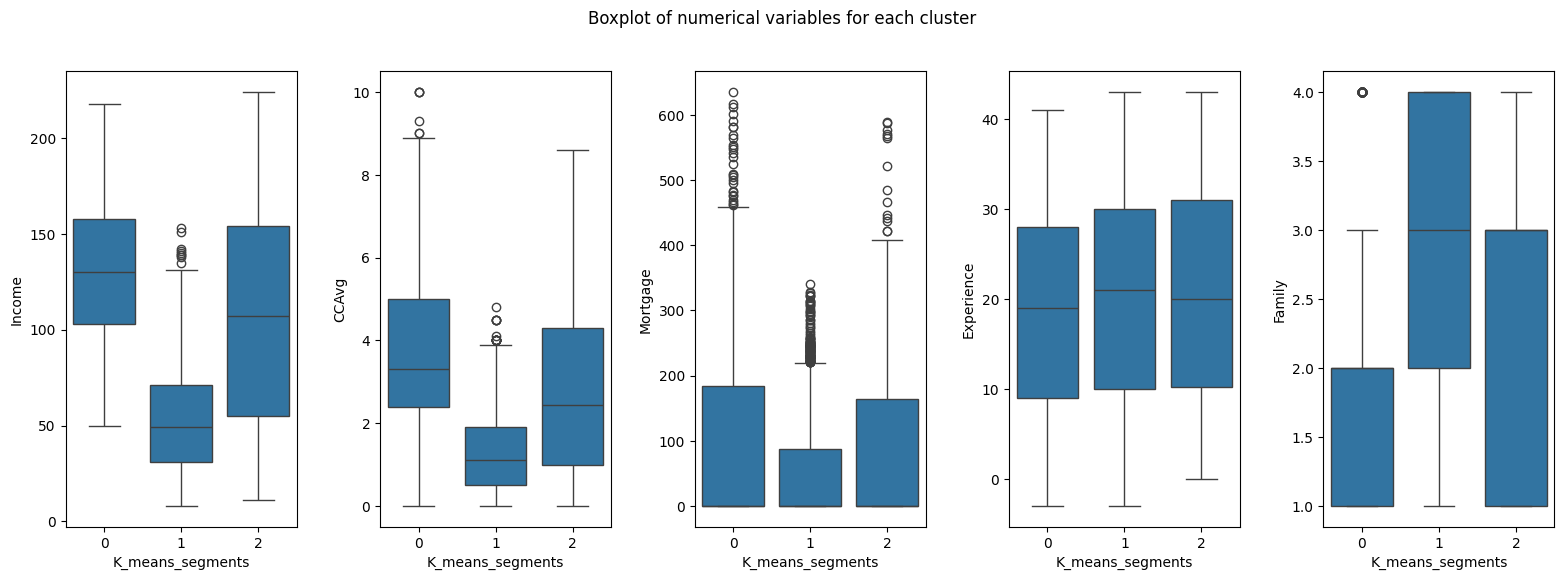

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of numerical variables for each cluster")
counter = 0
for i in range(5):
    sns.boxplot(ax=axes[i], y=df1[plot_cols[counter]], x=df1["K_means_segments"])
    counter = counter + 1

fig.tight_layout(pad=2.0)

Observations :

Cluster 0 : High Income & High Spending Customers
* Highest average income among all clusters.
* Highest credit card spending (CCAvg).
* Moderate personal loan acceptance.
* Low CD account ownership.
* Moderate online banking usage.

Interpretation
These customers are financially strong and actively spend through credit cards, making them good candidates for premium financial products.


Cluster 1 — Conservative / Low Engagement Customers
* Lowest income and lowest credit card spending.
* Lowest personal loan acceptance rate.
* Largest customer segment.
* No CD account ownership.
* Moderate online usage.

Interpretation
This segment represents low-value or conservative customers with limited engagement in advanced banking products.

Cluster 2 — Premium & Highly Engaged Customers
* High income and high spending behavior.
* Highest personal loan acceptance rate.
* Highest CD account ownership.
* Highest online banking and credit card usage.
* Financially active customers.

Interpretation
This is the most valuable customer segment for the bank, as these customers are highly engaged and most likely to accept personal loan offers.

Insights :
* Income is a Major Driver.
* Spending Behavior Impacts Loan Acceptance.
* CD Account Holders are High-Value Customers.
* Digitally Active Customers are More Responsive.
* Large Portion of Customers are Low Engagement Users.

Recommendations :

Target Cluster 2 Aggressively.
The bank should prioritize Cluster 2 customers for future personal loan campaigns because they:

* Have the highest conversion probability
* Are digitally active
* Already trust banking products
* Show strong financial engagement.

Reduce Broad Marketing on Cluster 1.
Mass marketing efforts on Cluster 1 may produce lower returns because:
* Loan acceptance is minimal
* Financial engagement is low
* Customers appear conservative

Instead, the bank can use low-cost awareness campaigns for this segment.